In [1]:
using Plots
using StatsPlots
using JLD2
using MPSTime
using StatsBase
using Measures
# using Makie
# using CairoMakie

In [2]:
files_raw = readdir(".")

17-element Vector{String}:
 "eta_nsweeps.ipynb"
 "eta_nsweeps_1.jld2"
 "eta_nsweeps_10.jld2"
 "eta_nsweeps_11.jld2"
 "eta_nsweeps_12.jld2"
 "eta_nsweeps_13.jld2"
 "eta_nsweeps_14.jld2"
 "eta_nsweeps_15.jld2"
 "eta_nsweeps_16.jld2"
 "eta_nsweeps_2.jld2"
 "eta_nsweeps_3.jld2"
 "eta_nsweeps_4.jld2"
 "eta_nsweeps_5.jld2"
 "eta_nsweeps_6.jld2"
 "eta_nsweeps_7.jld2"
 "eta_nsweeps_8.jld2"
 "eta_nsweeps_9.jld2"

In [3]:
function get_ns(fname::String)
    i_start = 13
    i_end = i_start
    while fname[i_end] !== '.'
        i_end +=1
    end
    return parse(Int, fname[i_start:i_end-1]) 

end

get_ns (generic function with 1 method)

In [4]:
res_by_sweep = Dict{Int, Any}()
for file in files_raw
    if length(file) > 5 && file[end-4:end] == ".jld2"
        ns = get_ns(file)
        @load file res
        res_by_sweep[ns] = res[1]
    end

end

In [5]:
res = Vector(undef, maximum(keys(res_by_sweep)))

for (k,v) in pairs(res_by_sweep)
    res[k] = v
end
    

In [8]:
function hm_convert(xs,ys,zs, annotations=false; verbosity=0)
    xs_full = range(extrema(xs)...)
    ys_full = range(extrema(ys)...)

    zs_full = Matrix{Union{Float64,Missing}}(missing, length(ys_full), length(xs_full))

    scale = ones(Int, size(zs_full)...)
    dupes = 0
    n = length(zs)
    anns = Dict{Tuple, Any}()
    for (i, z) in enumerate(zs)
        xi = findfirst(==(xs[i]), xs_full)
        yi = findfirst(==(ys[i]), ys_full)

        if ismissing(zs_full[yi, xi])
            zs_full[yi, xi] = z

        else
            zs_full[yi, xi] += z
            scale[yi, xi] += 1
            dupes += 1
        end
        anns[xs[i], ys[i]] =  text("$(scale[yi,xi])", halign=:center, valign=:center, color=:white)

    end
    verbosity >= 1 && println("n=$n, Duplicates=$dupes")

    if annotations
        xs_ann, ys_ann, ts_ann = [],[],[]
        for ((x,y), text) in pairs(anns)
            push!(xs_ann, x)
            push!(ys_ann, y)
            push!(ts_ann, text)
        end
        return xs_full, ys_full, (zs_full ./= scale), (xs_ann, ys_ann, ts_ann)

    else

        return xs_full, ys_full, (zs_full ./= scale)
    end
end

function loss_opts(res; verbosity=0)
    losses = getindex.(res,"loss") .|> mean
    opts = getindex.(res, "opts")

    ds = getproperty.(opts, :d)
    chis = getproperty.(opts, :chi_max)
    etas = getproperty.(opts, :eta)
    nsw = getproperty.(opts, :nsweeps)
    return losses, ds, chis, nsw, etas
end

function get_hm_vals(res, annotations=true; verbosity=0)
    losses, ds, chis, nsw, etas = loss_opts(res; verbosity=verbosity)
    return hm_convert(chis, ds, losses, annotations; verbosity=verbosity)
end

function map_dupes(res; verbosity=0)
    losses, ds, chis, nsw, etas = loss_opts(res; verbosity=verbosity)
    pairs = zip(ds, chis, nsw) |> collect
    return countmap(pairs)
end

map_dupes (generic function with 1 method)

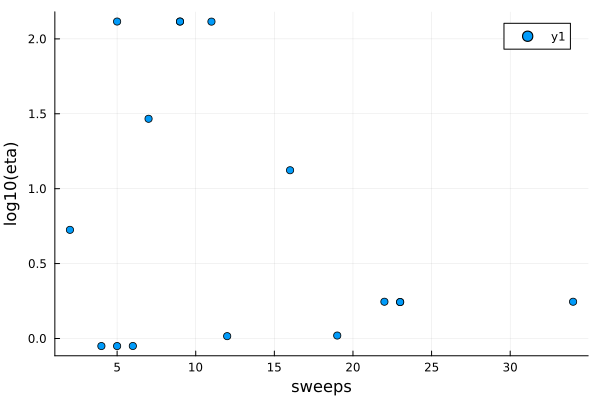

In [9]:
ds, chis, losses, nsw, etas = loss_opts(res)
scatter(nsw,log10.(etas);)
xlabel!("sweeps")
ylabel!("log10(eta)")

In [21]:
caches = getindex.(res, "cache")

ns_by_vec = []
loss_by_vec = []
etas_by_vec = []


for run in caches
    losses = Vector{Float64}(undef, length(run))
    etas = Vector{Float64}(undef, length(run))
    ns = Vector{Float64}(undef, length(run))
    i = 1
    for (params, loss) in pairs(run)
        losses[i] = loss
        ns[i] = params[2]
        etas[i] = params[1]
        i += 1
    end
    push!(loss_by_vec, losses)
    push!(etas_by_vec,etas)
    push!(ns_by_vec, ns)
end

UndefVarError: UndefVarError: `i` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [19]:
function makecmap(cm, data)
    d = vcat(data...)
    shift = minimum(d)
    d .-= shift
    scale = maximum(d)

    function cmap(cs)
        cc = deepcopy(cs)
        @. cs = (cs - shift) / scale
        return [cm[i] for i in cs]  
    end

    return cmap
end

makecmap (generic function with 1 method)

In [24]:
etas_by_vec[1] |> maximum

33.49654391578276

In [73]:
function deduplicate(xs,ys,zs; verbosity=0, annotations::Bool=false)
    xs_full = range(extrema(xs)...) |> collect
    ys_full = sort(unique(ys))

    zs_full = Matrix{Union{Float64,Missing}}(missing, length(ys_full), length(xs_full))

    scale = ones(Int, size(zs_full)...)
    dupes = 0
    n = length(zs)
    anns = Dict{Tuple, Any}()
    for (i, z) in enumerate(zs)
 
        yi = findfirst(==(ys[i]), ys_full)
        xi = findfirst(==(xs[i]), xs_full)
        if ys[i] <= 0 || isnothing(xi) || isnothing(yi)
            if ~(isnothing(xi) || isnothing(yi))
                ys_full[yi] = minimum(abs.(ys_full))
            end
            continue
        end 


        if ismissing(zs_full[yi, xi])
            zs_full[yi, xi] = z

        else
            zs_full[yi, xi] += z
            scale[yi, xi] += 1
            dupes += 1
        end
        anns[xs[i], ys[i]] =  text("$(scale[yi,xi])", halign=:center, valign=:center, color=:white)

    end
    verbosity >= 1 && println("n=$n, Duplicates=$dupes")

    if annotations
        xs_ann, ys_ann, ts_ann = [],[],[]
        for ((x,y), text) in pairs(anns)
            push!(xs_ann, x)
            push!(ys_ann, y)
            push!(ts_ann, text)
        end
        return xs_full, ys_full, (zs_full ./= scale), (xs_ann, ys_ann, ts_ann)

    else

        return xs_full, ys_full, (zs_full ./= scale)
    end
end

deduplicate (generic function with 1 method)

In [74]:
xs, ys, zs = deduplicate(vcat(ns_by_vec...), vcat(etas_by_vec...), vcat(loss_by_vec...))

([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0  …  34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0], [1.759188996883488, 1.759188996883488, 2.9853826189179604, 4.038778168243261, 4.194268704891817, 4.355745533923885, 4.49151214271235, 4.631510534996509, 4.719823749490465, 4.80982091218994  …  117929.91744547561, 120110.35643863506, 124740.11665488154, 134541.22830851533, 134541.22830851545, 147881.2798959856, 182065.42288626154, 246358.5819298125, 286568.56556640664, 333337.65304351825], Union{Missing, Float64}[missing missing … missing missing; missing 0.1655464484954355 … missing missing; … ; missing missing … missing missing; missing 0.1794465675462976 … missing missing])

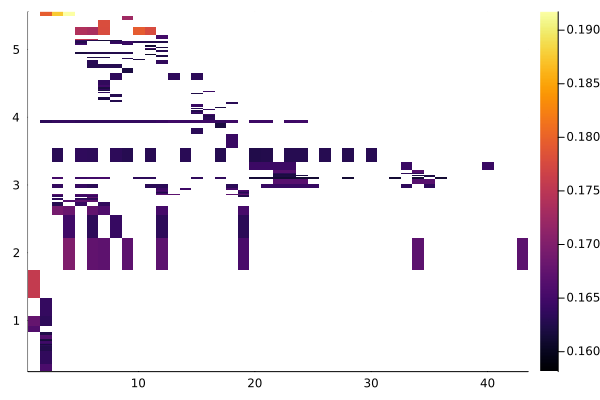

In [75]:

heatmap(xs,log10.(ys),zs)

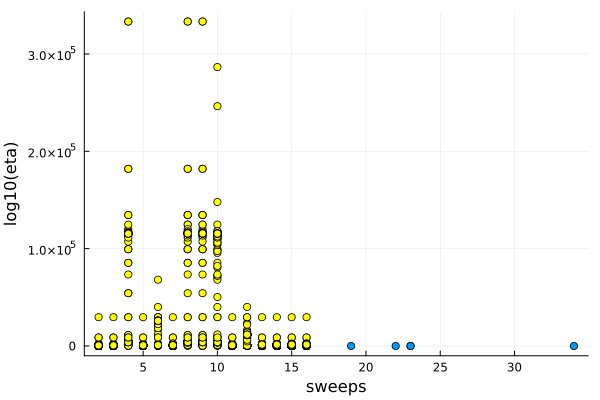

In [26]:
c = cgrad([:green, :yellow])
cmap = makecmap(c, loss_by_vec)

for i in 2:16
    scatter!([i for _ in etas_by_vec[i]], etas_by_vec[i]; markercolour=cmap(etas_by_vec[i]), legend=:none)
end
xlabel!("sweeps")
ylabel!("log10(eta)")